# Simulation Data

## EMD, MSE, MAE

Saved /nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/disentanglement/emd.csv
Saved /nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/disentanglement/mse.csv
Saved /nfs/team361/sb75/mintflow-reproducibility/artifacts/benchmarking/results/disentanglement/mae.csv


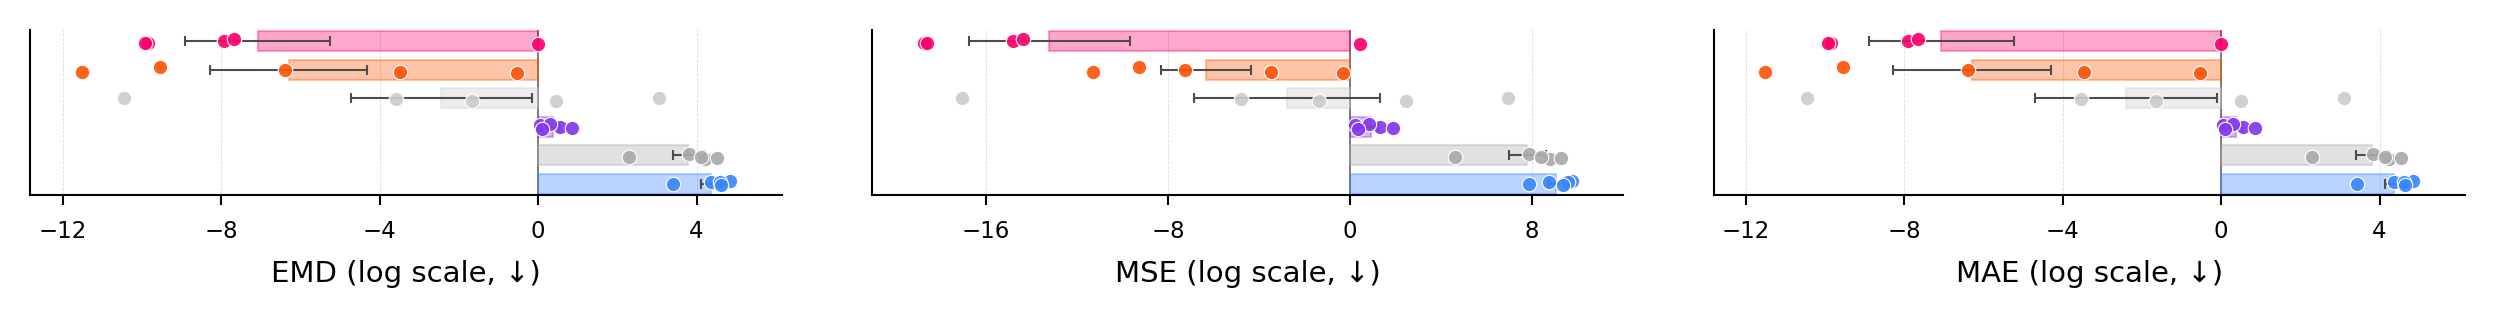


Saved disentanglement_combined.pdf / .svg / .png


In [3]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ── Column mapping & colours ────────────────────────────────────────────
rename = {
    "mefisto":       "MEFISTO",
    "simvi":         "SIMVI",
    "inflow":        "MintFlow",
    "NiCo":          "NiCo",
    "random":        "Random (uniform)",
    "random_binary": "Random (binary)",
}

method_colors = {
    "MEFISTO":            "#3A86FF",
    "SIMVI":              "#8338EC",
    "MintFlow":           "#FF006E",
    "NiCo":               "#FB5607",
    "Random (uniform)":   "#AAAAAA",
    "Random (binary)":    "#CCCCCC",
}


# ── Helper: plot one metric into an axes ────────────────────────────────
def plot_panel(ax, df, measname, show_ylabels=True):
    """Plot a single metric panel."""
    methods = list(df.columns)
    means = df.mean()
    sems = df.sem()
    y = np.arange(len(methods))
    bar_height = 0.7

    # Horizontal bars
    ax.barh(
        y, means, height=bar_height,
        color=[method_colors[m] for m in methods],
        edgecolor=[method_colors[m] for m in methods],
        linewidth=0.5,
        alpha=0.35,
        zorder=2,
    )

    # Error bars (SEM)
    ax.errorbar(
        means, y, xerr=sems,
        fmt="none",
        ecolor="0.3",
        elinewidth=0.5,
        capsize=1.2,
        capthick=0.5,
        zorder=3,
    )

    # Individual data points (jittered strip)
    rng = np.random.default_rng(42)
    jitter_width = 0.12
    for i, method in enumerate(methods):
        x_vals = df[method].values
        y_jitter = rng.uniform(-jitter_width, jitter_width, size=len(x_vals))
        ax.scatter(
            x_vals, i + y_jitter,
            s=12,
            color=method_colors[method],
            edgecolors="white",
            linewidths=0.3,
            zorder=4,
            alpha=0.92,
        )

    # Axes styling
    ax.set_yticks(y)
    if show_ylabels:
        ax.set_yticklabels(methods, fontweight="medium")
    else:
        ax.set_yticklabels([])

    ax.axvline(0, color="0.4", linewidth=0.4, zorder=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(-0.4, len(methods) - 0.6)
    ax.invert_yaxis()

    x_min = df.min().min()
    x_max = df.max().max()
    x_pad = (x_max - x_min) * 0.08
    ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ax.xaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=False))

    ax.set_xlabel(f"{measname} (log scale, \u2193)", fontweight="medium")


# ── Load data ───────────────────────────────────────────────────────────
DATA_DIR = (
    "/nfs/team361/aa36/OnGit/mintflow-benchmarking/Metrics/"
    "1_Disentanglement/3_Actual_Benchmarks/NonGit/ToMakeFigs/Synthetic/"
)
OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/disentanglement"
)
os.makedirs(OUT_DIR, exist_ok=True)

metric_names = ["EMD", "MSE", "MAE"]
dataframes = {}

for measname in metric_names:
    with open(
        os.path.join(DATA_DIR, f"boxplots_{measname}_NOregiondiscard.pkl"),
        "rb",
    ) as f:
        dict_content = pickle.load(f)

    dict_methodname_to_npvals = dict_content["dict_methodname_to_npvals"]

    df_results = pd.DataFrame(
        np.stack(
            [
                np.log(dict_methodname_to_npvals[methodname] + 1e-10).mean(1)
                for methodname in dict_methodname_to_npvals.keys()
            ],
            -1,
        ),
        columns=list(dict_methodname_to_npvals.keys()),
    )

    # Rename columns
    col_rename = {k: v for k, v in rename.items() if k in df_results.columns}
    df_results = df_results.rename(columns=col_rename)

    # Keep only known methods
    ordered = [m for m in method_colors.keys() if m in df_results.columns]
    df_results = df_results[ordered]

    # Save CSV
    csv_path = os.path.join(OUT_DIR, f"{measname.lower()}.csv")
    df_results.to_csv(csv_path, index=False)
    print(f"Saved {csv_path}")

    dataframes[measname] = df_results

# ── Sort methods by average rank across all metrics (best on top) ───────
# For each metric, rank methods by mean (lower = better = rank 1)
rank_df = pd.DataFrame({
    meas: dataframes[meas].mean().rank()
    for meas in metric_names
})
avg_rank = rank_df.mean(axis=1).sort_values()
sorted_methods = avg_rank.index.tolist()

# Reorder all dataframes consistently
for meas in metric_names:
    cols = [m for m in sorted_methods if m in dataframes[meas].columns]
    dataframes[meas] = dataframes[meas][cols]

# ── Create 1×3 panel figure ─────────────────────────────────────────────
n_methods = len(sorted_methods)
panel_width = 65 * mm    # wider panels to span full row
row_height = 0.12        # match AUC/NLL height
fig_height = n_methods * row_height + 0.35
fig_width_total = panel_width * 3 + 0.65  # extra for y-labels on left

fig, axes = plt.subplots(
    1, 3,
    figsize=(fig_width_total, fig_height),
    sharey=True,
)

for i, measname in enumerate(metric_names):
    plot_panel(axes[i], dataframes[measname], measname, show_ylabels=(i == 0))

plt.tight_layout()
plt.subplots_adjust(wspace=0.12)

# ── Save combined figure ────────────────────────────────────────────────
for ext in ["pdf", "svg", "png"]:
    fig.savefig(
        os.path.join(OUT_DIR, f"disentanglement_combined.{ext}"),
        bbox_inches="tight",
        pad_inches=0.05,
    )
plt.show()
plt.close()
print("\nSaved disentanglement_combined.pdf / .svg / .png")